# Global Renewable Energy Shift Analysis 2000-2025

## Tracking the Global Electricity Transition

This notebook analyzes how electricity generation changed across 309 countries and regions between 2000 and 2025 using data from Our World in Data and Ember.

The dataset includes electricity generation and electricity share metrics across solar, wind, hydro, nuclear, coal, gas, oil, and other energy sources. The analysis focuses on long-term transition patterns, renewable adoption trends, fossil fuel dependence, and large-scale electricity system changes.

The notebook combines exploratory analysis, visualization.

### Topics Covered

- Dataset structure and quality checks
- Missing value analysis
- Global renewable electricity trends
- Fossil fuel dependency patterns
- Solar, wind, hydro, and nuclear growth
- Country-level transition comparisons
- Coal dependency across major economies
- Correlation analysis
- Country clustering and segmentation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

In [29]:
df = pd.read_csv(r'renewable_energy_share_2000_2025.csv')

print(f'Data shape : {df.shape}')
df.head(10)

Data shape : (7636, 33)


,country,year,iso_code,population,gdp,primary_energy_consumption,electricity_generation,electricity_demand,renewables_share_energy,renewables_share_elec,...,solar_share_elec,wind_share_elec,hydro_share_elec,nuclear_share_elec,coal_share_elec,gas_share_elec,energy_per_capita,renewables_energy_per_capita,fossil_energy_per_capita,renewables_cons_change_twh
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,378.76,378.76,NaN,19.334,...,0.000,0.000,13.314,0.0,20.073,43.368,NaN,NaN,NaN,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,405.09,405.09,NaN,19.055,...,0.000,0.000,13.412,0.0,21.294,47.004,NaN,NaN,NaN,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,433.19,433.19,NaN,17.667,...,0.000,0.000,12.304,0.0,21.568,48.228,NaN,NaN,NaN,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,458.30,458.30,NaN,16.668,...,0.000,0.000,11.610,0.0,22.258,49.424,NaN,NaN,NaN,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,496.61,496.61,NaN,15.696,...,0.000,0.000,10.670,0.0,23.159,49.165,NaN,NaN,NaN,NaN
5,ASEAN (Ember),2005,NaN,NaN,NaN,NaN,522.68,522.68,NaN,15.151,...,0.000,0.004,10.308,0.0,23.825,48.462,NaN,NaN,NaN,NaN
6,ASEAN (Ember),2006,NaN,NaN,NaN,NaN,547.17,547.17,NaN,15.765,...,0.007,0.009,11.061,0.0,25.235,48.005,NaN,NaN,NaN,NaN
7,ASEAN (Ember),2007,NaN,NaN,NaN,NaN,578.98,578.98,NaN,15.686,...,0.007,0.010,10.924,0.0,26.892,47.328,NaN,NaN,NaN,NaN
8,ASEAN (Ember),2008,NaN,NaN,NaN,NaN,603.96,603.96,NaN,16.493,...,0.007,0.010,11.582,0.0,25.172,48.528,NaN,NaN,NaN,NaN
9,ASEAN (Ember),2009,NaN,NaN,NaN,NaN,624.57,624.57,NaN,16.698,...,0.006,0.011,11.799,0.0,26.064,49.445,NaN,NaN,NaN,NaN


# Columns Overview


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7636 entries, 0 to 7635
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       7636 non-null   object 
 1   year                          7636 non-null   int64  
 2   iso_code                      5549 non-null   object 
 3   population                    5846 non-null   float64
 4   gdp                           3800 non-null   float64
 5   primary_energy_consumption    6582 non-null   float64
 6   electricity_generation        6353 non-null   float64
 7   electricity_demand            6028 non-null   float64
 8   renewables_share_energy       2775 non-null   float64
 9   renewables_share_elec         6327 non-null   float64
 10  fossil_share_energy           2775 non-null   float64
 11  fossil_share_elec             6227 non-null   float64
 12  low_carbon_share_energy       2775 non-null   float64
 13  low

#we analysis of columns datatype which column need to change there datatype

In [4]:
df.describe()

,year,population,gdp,primary_energy_consumption,electricity_generation,electricity_demand,renewables_share_energy,renewables_share_elec,fossil_share_energy,fossil_share_elec,...,solar_share_elec,wind_share_elec,hydro_share_elec,nuclear_share_elec,coal_share_elec,gas_share_elec,energy_per_capita,renewables_energy_per_capita,fossil_energy_per_capita,renewables_cons_change_twh
count,7636.000000,5.846000e+03,3.800000e+03,6582.000000,6353.000000,6028.000000,2775.000000,6327.000000,2775.000000,6227.000000,...,6309.000000,6101.000000,6232.000000,6158.000000,6142.000000,6044.000000,5568.000000,2250.000000,2250.000000,2775.000000
mean,2012.001572,1.276241e+08,8.569239e+11,5018.383844,817.937738,672.103732,12.870698,31.021122,83.376731,64.841290,...,1.390995,2.135865,25.214571,4.675415,14.528162,20.264166,27081.161088,5575.919388,34839.358469,39.585714
std,7.261077,6.298665e+08,5.998881e+12,17775.362799,2844.887758,2647.544214,14.252426,31.133535,15.726514,32.008566,...,3.676046,5.477882,29.802112,11.677168,22.747873,27.545091,41614.305184,15780.778963,35480.992330,144.775123
min,2000.000000,1.776000e+03,3.128536e+08,0.000000,0.000000,0.000000,0.000000,0.000000,13.874000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,995.256000,-266.862000
25%,2006.000000,9.186292e+05,2.367882e+10,9.128250,1.120000,1.320000,2.987500,3.590500,76.436000,41.185500,...,0.000000,0.000000,0.291500,0.000000,0.000000,0.000000,3442.919750,455.058000,15475.631250,-0.087000
50%,2012.000000,6.882693e+06,7.808994e+10,83.446500,14.150000,11.285000,7.945000,20.000000,86.683000,71.403000,...,0.000000,0.000000,13.112000,0.000000,0.000000,8.382000,14232.815000,1915.476500,25559.820000,1.540000
75%,2018.000000,2.784505e+07,3.546080e+11,821.474500,119.960000,90.552500,18.012500,52.802000,95.664000,95.720500,...,0.821000,1.576000,43.309250,0.000000,24.918250,29.190750,36220.968750,4560.539250,40484.954250,12.175500
max,2025.000000,8.231613e+09,1.301126e+14,176737.094000,31772.350000,31772.350000,86.126000,100.000000,100.000000,100.000000,...,50.000000,58.214000,100.000000,82.253000,100.000000,100.000000,651836.562000,153153.984000,270980.594000,2164.578000


In [5]:
pd.DataFrame({
    "columns": df.columns,
    'datatype': df.dtypes.values,
    'missing_values': df.isna().sum().values,
    'mising_values_pct': (df.isna().mean()*100).round(2).values
}).sort_values('mising_values_pct', ascending=False)

,columns,datatype,missing_values,mising_values_pct
31,fossil_energy_per_capita,float64,5386,70.53
30,renewables_energy_per_capita,float64,5386,70.53
12,low_carbon_share_energy,float64,4861,63.66
8,renewables_share_energy,float64,4861,63.66
10,fossil_share_energy,float64,4861,63.66
32,renewables_cons_change_twh,float64,4861,63.66
4,gdp,float64,3836,50.24
2,iso_code,object,2087,27.33
29,energy_per_capita,float64,2068,27.08
3,population,float64,1790,23.44


# Basic Imformation About dataset

In [24]:
pd.DataFrame({
    "columns": df.columns,
    'datatype': df.dtypes.values,
    'missing_values': df.isna().sum().values,
    'mising_values_pct': (df.isna().mean()*100).round(2).values
}).sort_values('mising_values_pct', ascending=False)

,columns,datatype,missing_values,mising_values_pct
10,fossil_share_energy,float64,4861,63.66
8,renewables_share_energy,float64,4861,63.66
12,low_carbon_share_energy,float64,4861,63.66
4,gdp,float64,3836,50.24
2,iso_code,object,2087,27.33
29,energy_per_capita,float64,2068,27.08
21,biofuel_electricity,float64,1649,21.60
7,electricity_demand,float64,1608,21.06
28,gas_share_elec,float64,1592,20.85
19,gas_electricity,float64,1566,20.51


In [10]:
print(f"Total country : {df['country'].nunique()}")
print(f'Range of Year : {df['year'].min()} - {df['year'].max()}')
print(f'Total Mising (NaN) Values : {df.isnull().sum().sum()}')
print(f'Total mising (NaN) values % : {((df.isnull().sum().sum())/(df.shape[0]*df.shape[1])*100).round(2)}%')
print(f'Total Dupalicate : {df.duplicated().sum()}')

Total country : 309
Range of Year : 2000 - 2025
Total Mising (NaN) Values : 52394
Total mising (NaN) values % : 22.87%
Total Dupalicate : 0


# Clean The Dataset


In [25]:
df['population'].isnull().mean()*100

np.float64(0.0)

In [26]:
df['population'] = df['population'].fillna(0).astype('int')

In [ ]:
df.drop(columns=[
    'renewables_energy_per_capita',
    'fossil_energy_per_capita',
    'renewables_cons_change_twh'
], inplace=True)

# Mising Values Analysis

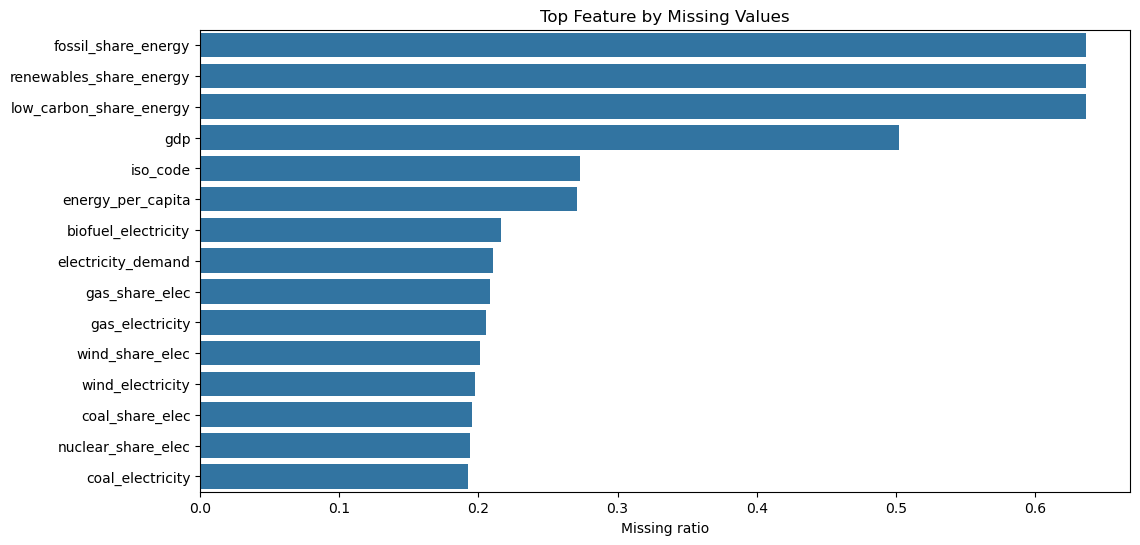

In [12]:
mising_values = (
    df.isna().
    mean().
    sort_values(ascending=False).
    reset_index()
    )
mising_values.columns = ['feature', 'mising_ratio']

plt.figure(figsize=(12,6))
sns.barplot(
    data=mising_values.head(15),
    x='mising_ratio', 
    y='feature'
            )

plt.title('Top Feature by Missing Values')
plt.xlabel('Missing ratio')
plt.ylabel('')
plt.show()


## Analysis

Missing values are concentrated in newer technologies and recently reported years. Solar and wind adoption expanded unevenly across countries, so earlier years naturally contain gaps for many regions.

The 2025 data is partially reported, which is expected because several countries have not yet published complete electricity statistics for the year.


## Global Renewable Electricity Share Over Time


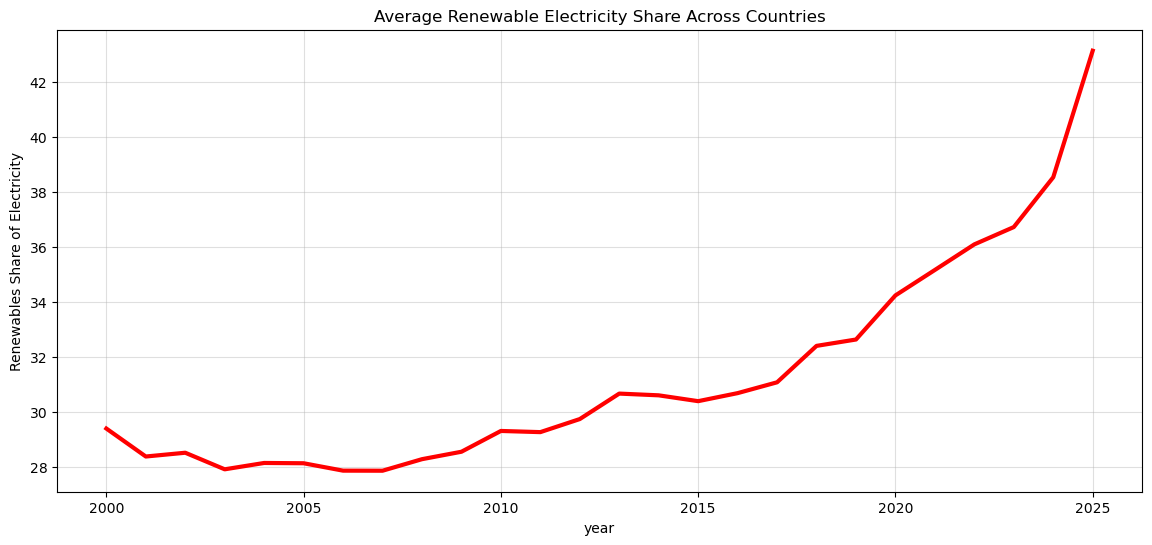

In [13]:
global_trend = (
    df.groupby('year')['renewables_share_elec'].
    mean().
    reset_index()
)

plt.figure(figsize=(14,6))
plt.plot(
    global_trend['year'],
    global_trend['renewables_share_elec'],
    linewidth=3,
    color='r'
)
plt.grid(linestyle = "-",visible=True, alpha=0.4)
plt.title("Average Renewable Electricity Share Across Countries")
plt.xlabel('year')
plt.ylabel('Renewables Share of Electricity')
plt.show()

## Analysis

The long-term trend clearly points upward. Renewable electricity adoption accelerated gradually during the early 2000s and then strengthened significantly after 2015.

The steepening slope during the later years reflects large-scale solar and wind deployment, especially across China, Europe, and parts of Latin America.

# Fossil Share Trend

Text(0, 0.5, 'Fossil Share of Electricity')

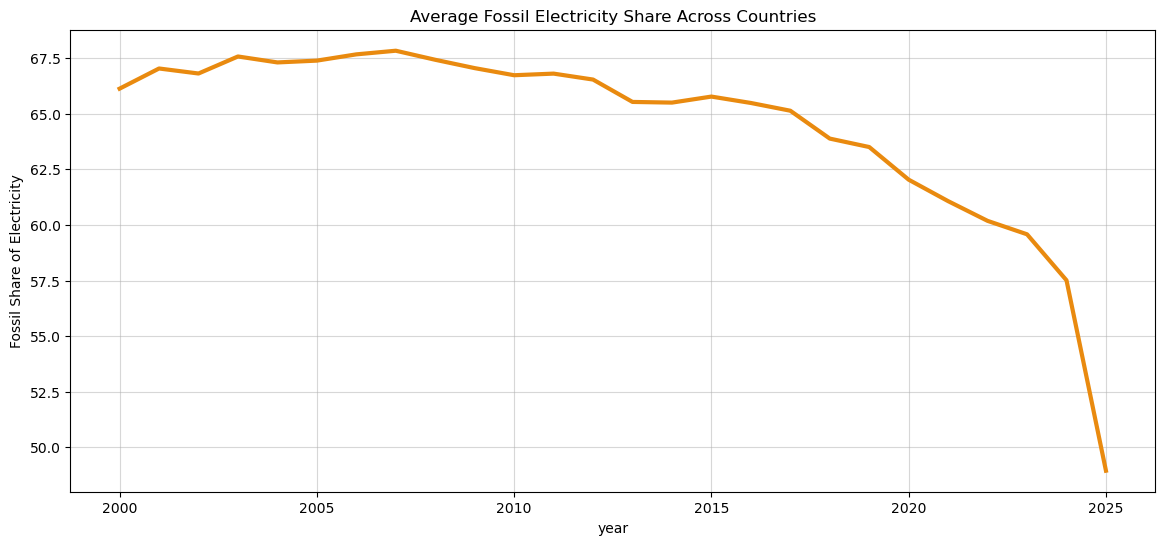

In [14]:
fossil_trend = (
    df.groupby('year')['fossil_share_elec'].
    mean().
    reset_index()
)

plt.figure(figsize=(14,6))
plt.plot(
    fossil_trend['year'],
    fossil_trend['fossil_share_elec'],
    linewidth=3,
    color="#e98a0f"
)
plt.grid(visible=True, alpha=0.5)

plt.title('Average Fossil Electricity Share Across Countries')
plt.xlabel('year')
plt.ylabel('Fossil Share of Electricity')


## Solar and Wind Expansion


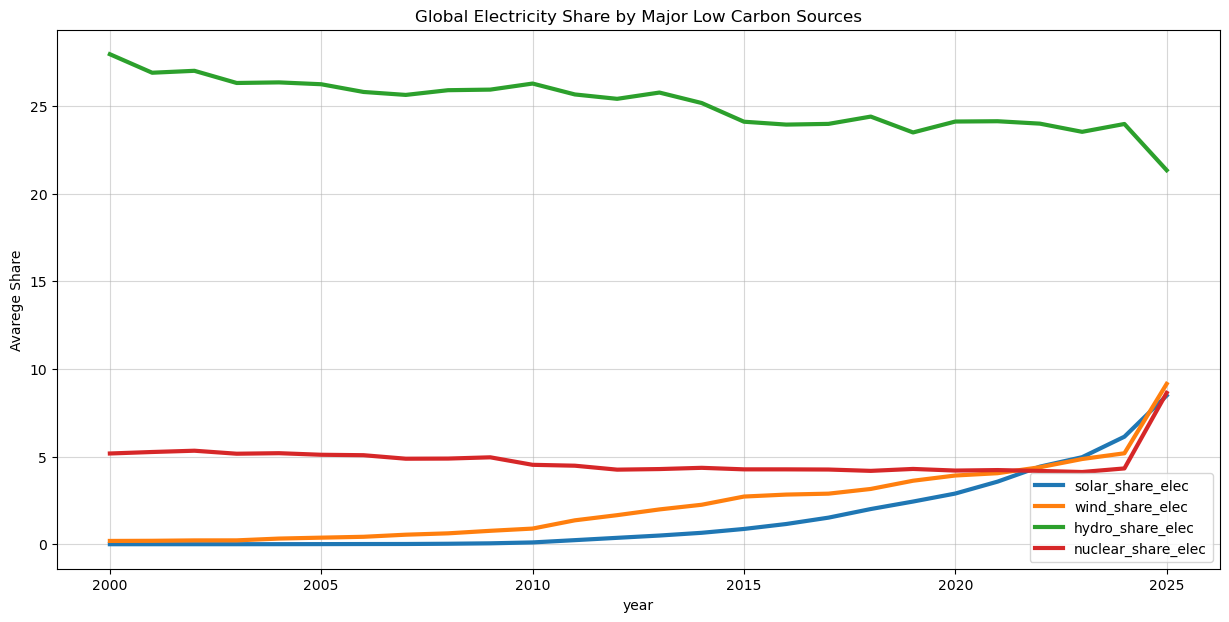

In [15]:
source_trend = (
    df.groupby('year')[[
        "solar_share_elec",
        "wind_share_elec",
        "hydro_share_elec",
        "nuclear_share_elec"
    ]].mean()
)

plt.figure(figsize=(15,7))
for col in source_trend.columns:
    plt.plot(
        source_trend.index,
        source_trend[col],
        linewidth=3,
        label= col
    )
plt.legend()
plt.grid(visible=True, alpha=0.5)
plt.title('Global Electricity Share by Major Low Carbon Sources')
plt.xlabel('year')
plt.ylabel('Avarege Share')
plt.show()

<Axes: xlabel='gdp', ylabel='country'>

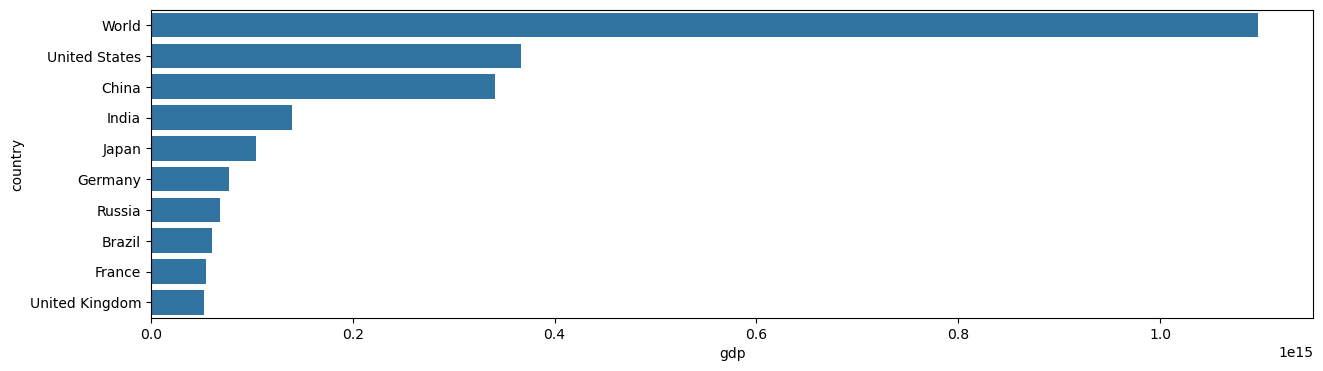

In [16]:
gdp_ranking =(
    df.groupby('country')['gdp'].sum().sort_values(ascending=False).reset_index().head(10)
)

plt.figure(figsize=(15,4))
sns.barplot(
    x=gdp_ranking['gdp'],
    y=gdp_ranking['country']
    )



## Countries With Highest Renewable Share in Latest Year


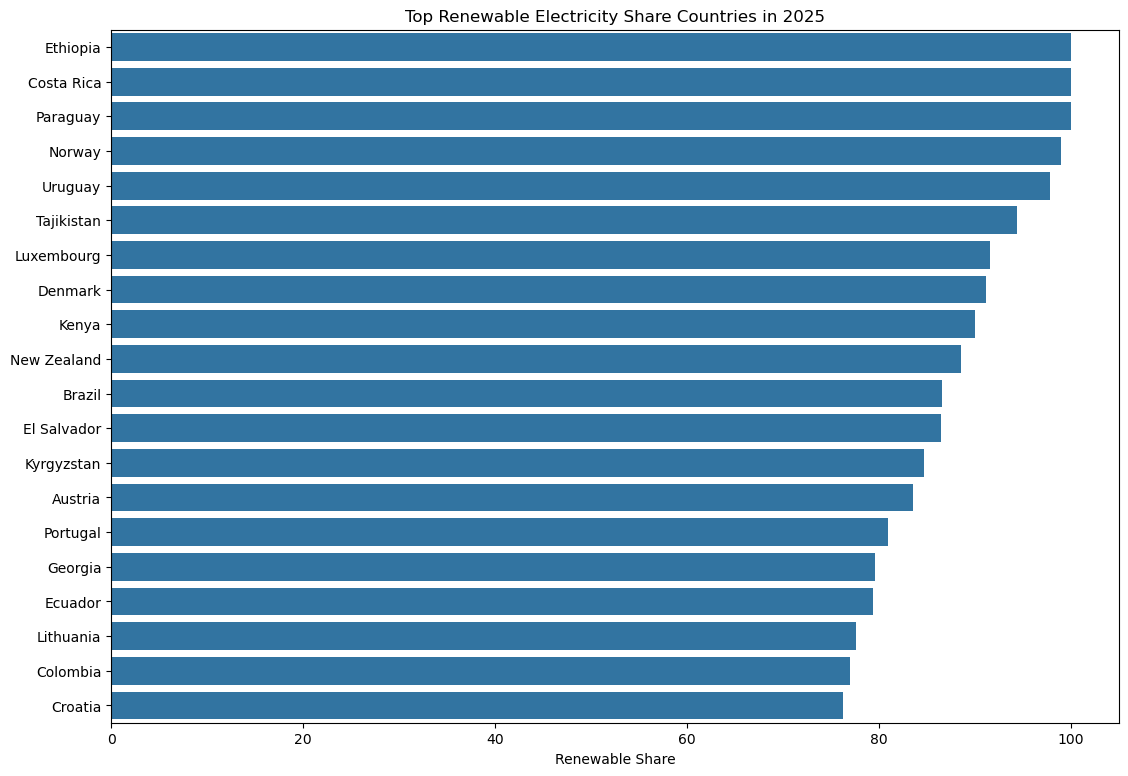

,country,renewables_share_elec
2136,Ethiopia,100.000
1538,Costa Rica,100.000
5686,Paraguay,100.000
4926,Norway,98.999
7319,Uruguay,97.822
6787,Tajikistan,94.366
3765,Luxembourg,91.558
1742,Denmark,91.171
3383,Kenya,90.028
4534,New Zealand,88.533


In [17]:
latest_year = (df['year'].max())

latest_df = (
    df[df['year'] == latest_year].
    dropna(subset=('renewables_share_elec'))
)

top_renewable = (
    latest_df.sort_values("renewables_share_elec",ascending=False).
    head(20)
)

plt.figure(figsize=(13,9))
sns.barplot(
    x=top_renewable['renewables_share_elec'],
    y=top_renewable['country']
)

plt.title(f"Top Renewable Electricity Share Countries in {latest_year}")
plt.xlabel('Renewable Share')
plt.ylabel('')
plt.show()

top_renewable[["country", "renewables_share_elec"]]

## Analysis

Most countries at the top of the renewable ranking are hydro-dominated systems with smaller populations and favorable geography.

Large economies rarely achieve near-100% renewable electricity because industrial demand, grid stability requirements, and legacy fossil infrastructure create additional constraints.


## Largest Renewable Growth Since 2000


<Axes: xlabel='growth', ylabel='country'>

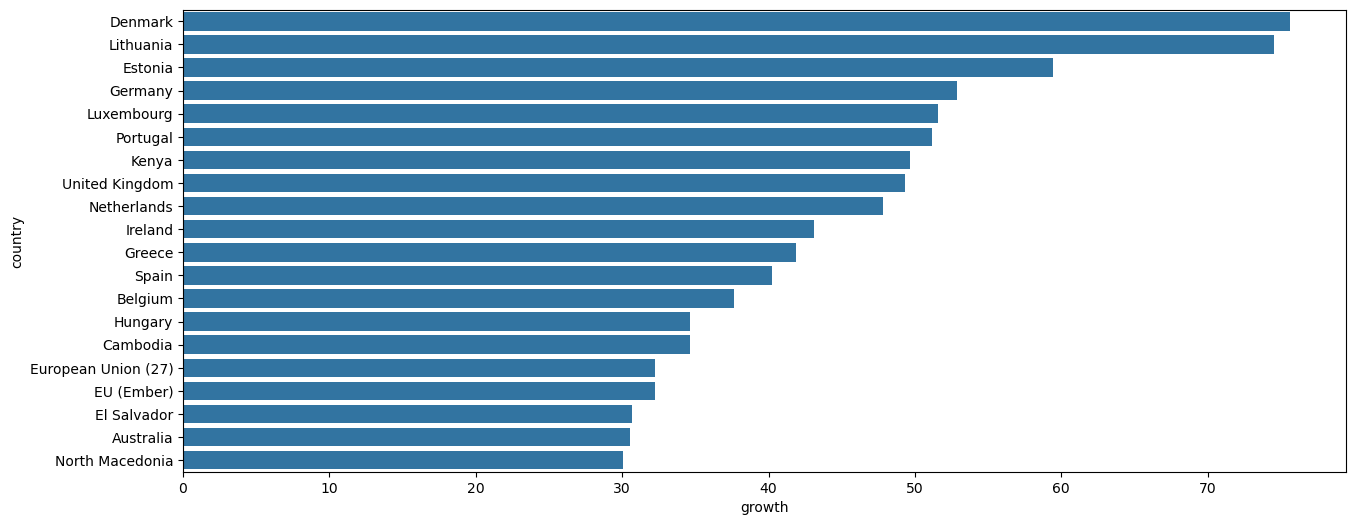

In [18]:
base_year = (
    df[df["year"] == 2000][
        ["country", "renewables_share_elec"]
    ]
    .rename(columns={
        "renewables_share_elec": "renewables_2000"
    })
)

latest_year_df =(
    df[df['year'] == latest_year][
        ['country', 'renewables_share_elec']
    ]
    .rename(columns={
        'renewables_share_elec':'renewables_2025'
    })
)

growth_df =(
    base_year.merge(
        latest_year_df,
        on='country',
        how='inner'
    )
)

growth_df['growth'] = (
    growth_df['renewables_2025'] - growth_df['renewables_2000']
)

growth_df = growth_df.sort_values(
    'growth',
    ascending=False
    )

plt.figure(figsize=(15,6))
sns.barplot(
    data=growth_df.head(20),
    x='growth',
    y='country'
)


## Analysis

The countries with the largest gains are not necessarily those with the highest absolute renewable share today.

This distinction matters because transition momentum often reveals more than current ranking alone. Several countries started from heavily fossil-based systems and achieved major structural shifts over the last two decades.


## Coal Dependency Comparison

This section compares coal dependence trajectories across major economies.


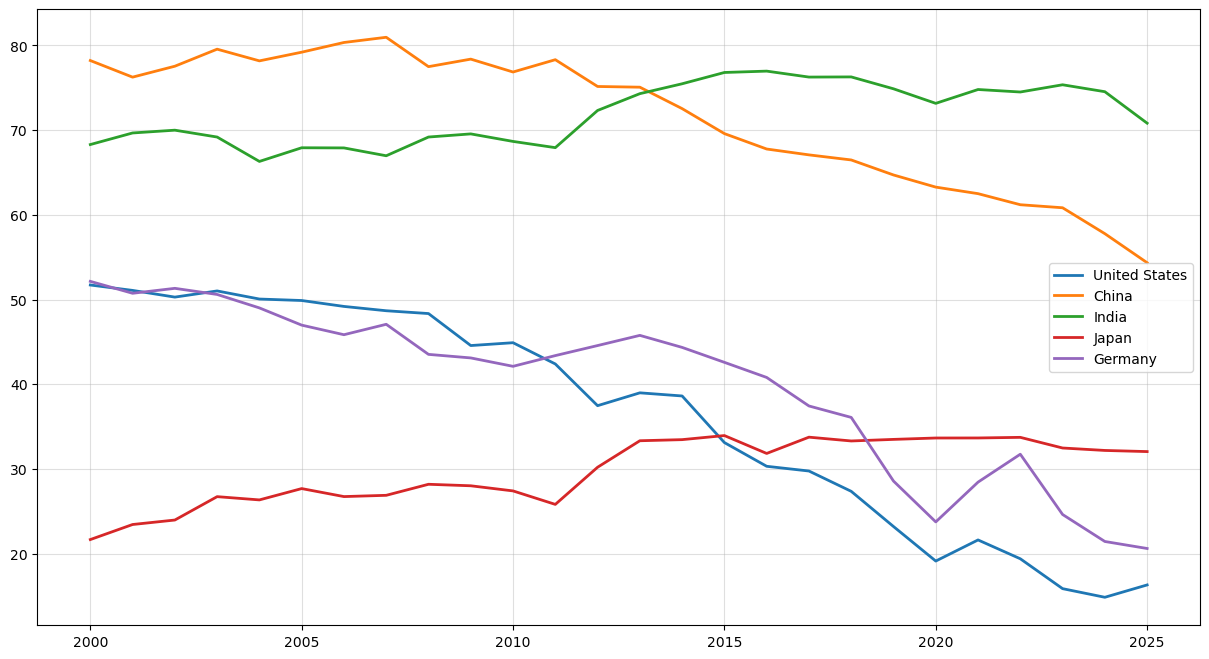

In [19]:
focus_contries =[
    "United States",
    "China",
    "India",
    "Japan",
    "Germany"
]

coal_df = (
    df[df['country'].isin(focus_contries)]
)

plt.figure(figsize=(15,8))

for contry in focus_contries:
    temp = coal_df[coal_df['country'] == contry]

    plt.plot(
        temp['year'],
        temp['coal_share_elec'],
        linewidth=2,
        label = contry
    )
    plt.legend()
    plt.grid(visible=True, alpha=0.4)

## Analysis

The coal trajectories differ sharply across major economies.

Germany shows a clear structural decline in coal usage over time, while China and India continue to rely heavily on coal due to industrial demand and rapidly growing electricity consumption.

The United States exhibits a meaningful reduction driven by natural gas substitution and renewable expansion.


## Correlation Matrix


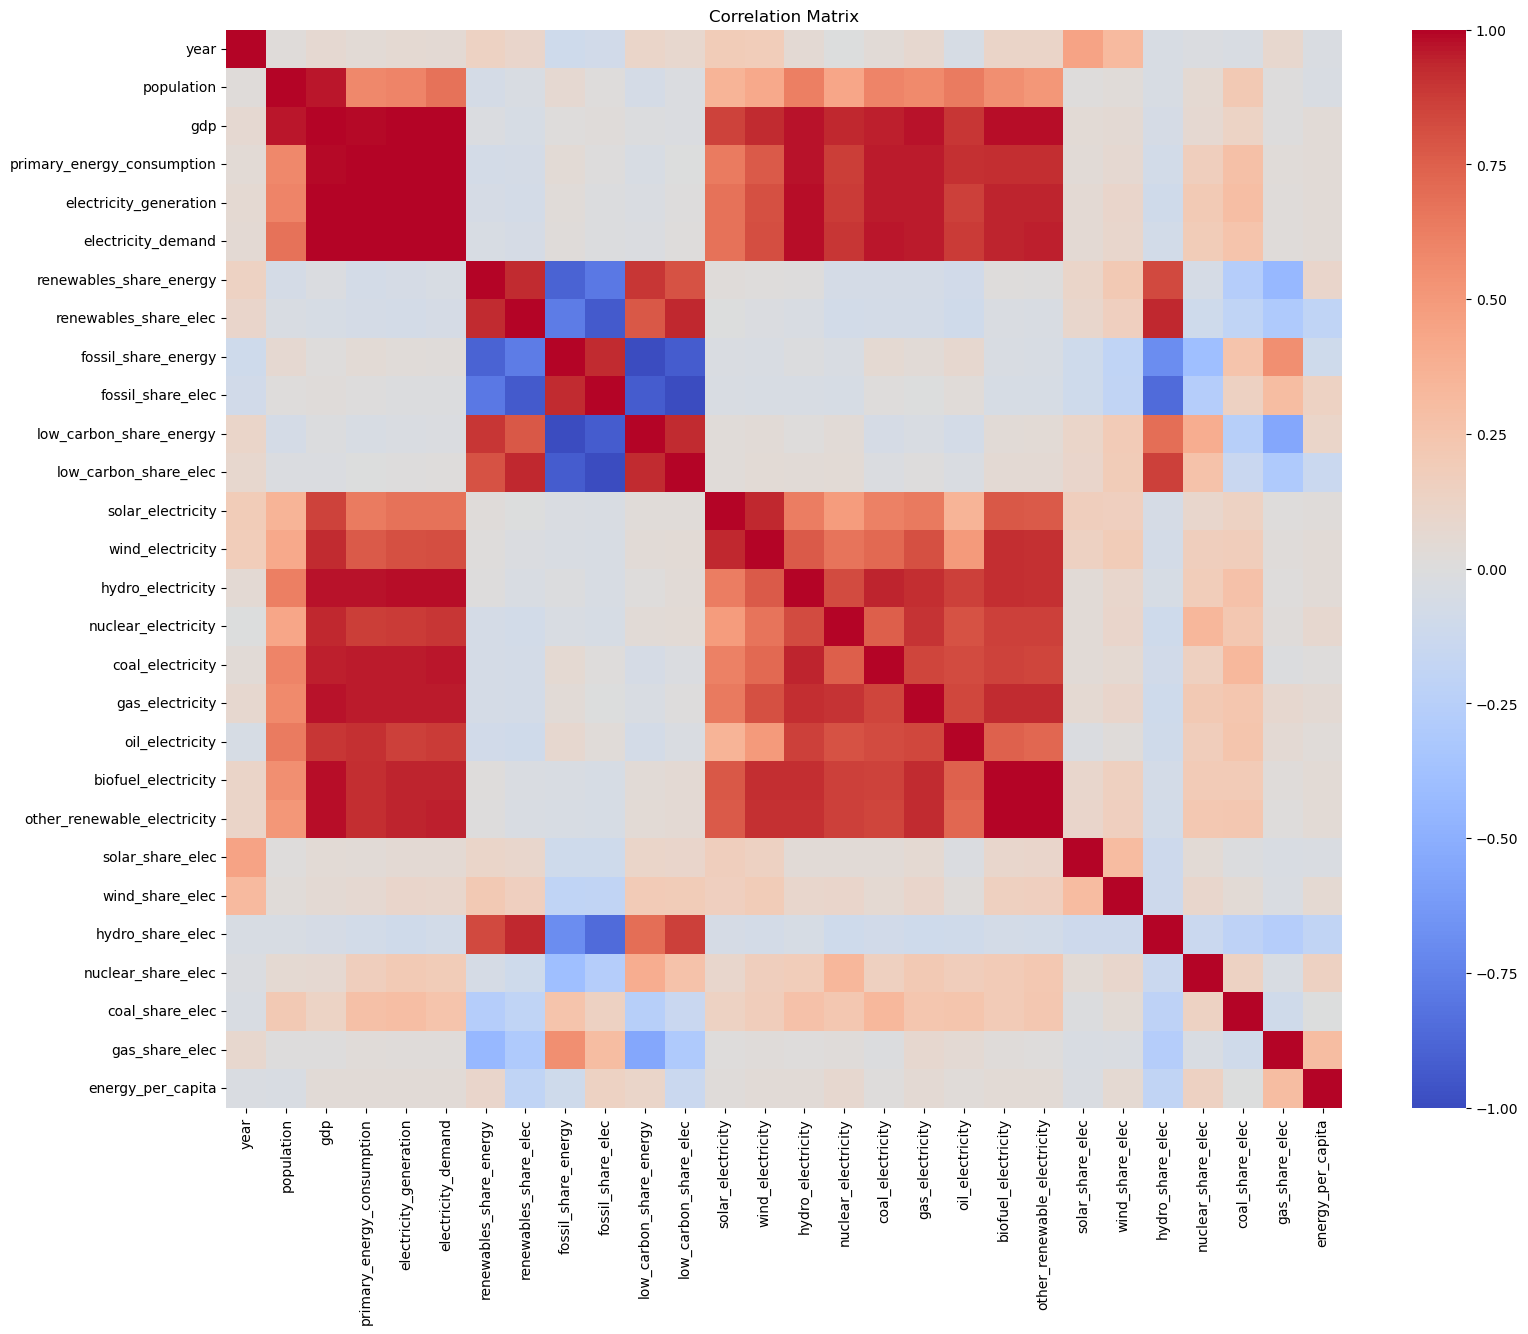

In [20]:
numeric_cols = df.select_dtypes(include=np.number).columns

corr_matrix = (
    df[numeric_cols]
    .corr()
)

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

## Analysis

Strong negative relationships appear between renewable and fossil electricity shares, which is expected because electricity mix components compete within a finite generation system.

Hydro-heavy systems often behave differently from solar- and wind-driven systems, which creates interesting sub-structures inside the correlation matrix.


## Renewable vs Fossil Electricity Relationship


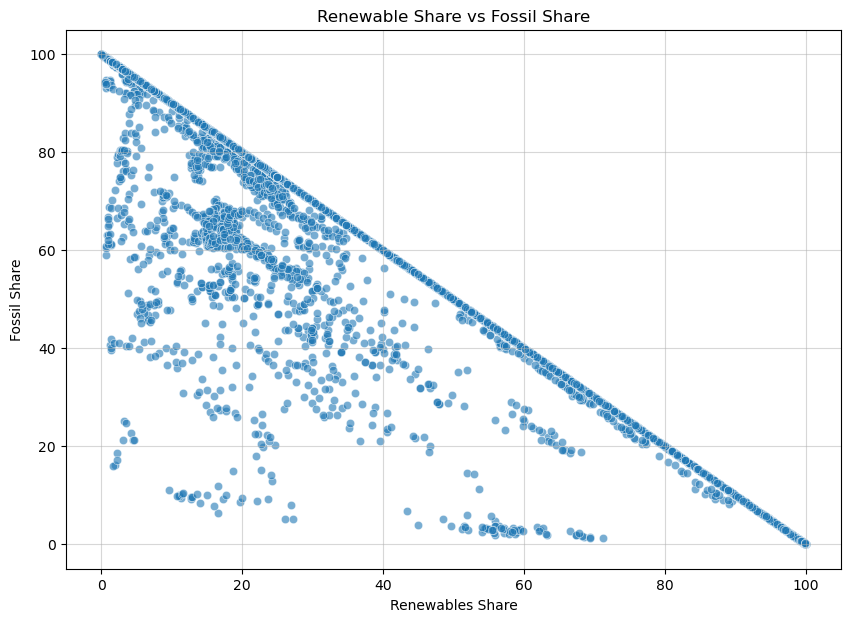

In [21]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="renewables_share_elec",
    y="fossil_share_elec",
    alpha=0.6
)

plt.title("Renewable Share vs Fossil Share")
plt.xlabel("Renewables Share")
plt.ylabel("Fossil Share")
plt.grid(visible=True, alpha=0.5)
plt.show()


## Analysis

The inverse relationship between renewable and fossil electricity shares is visually clear.

However, the spread around the trend line also shows that countries can maintain mixed systems where renewables grow without immediately eliminating fossil generation.


## Per Capita Energy Consumption Distribution


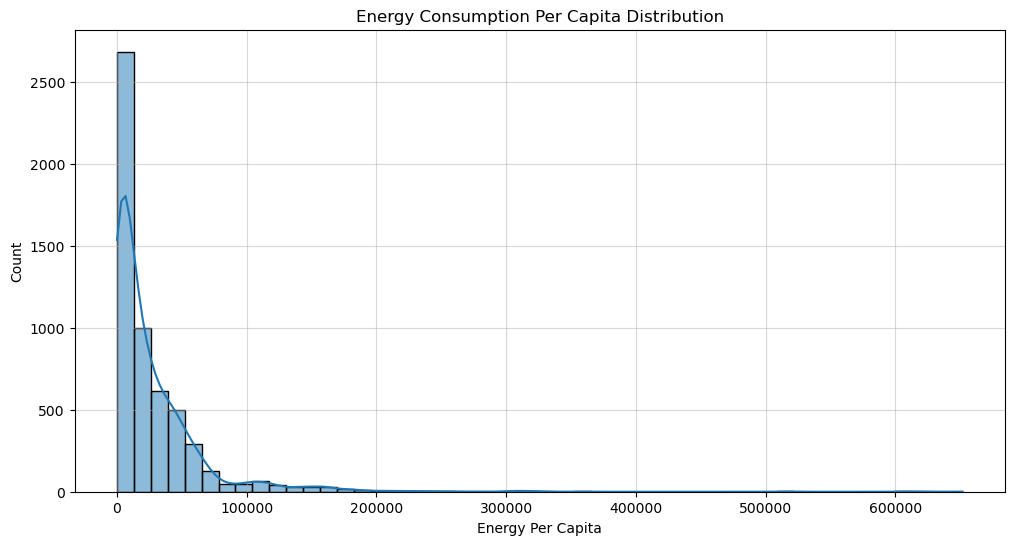

In [22]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["energy_per_capita"],
    bins=50,
    kde=True
)

plt.title("Energy Consumption Per Capita Distribution")
plt.xlabel("Energy Per Capita")
plt.grid(visible=True, alpha=0.5)
plt.show()

## Analysis

The distribution is heavily right-skewed.

A small number of high-income or energy-exporting countries consume far more energy per capita than the global median. Most countries cluster within a much lower consumption range.


## Renewable Electricity Leaders by Region Size

Small countries can reach 100% renewable electricity more easily. To identify large-scale transition leaders, the next section filters countries with meaningful electricity generation.


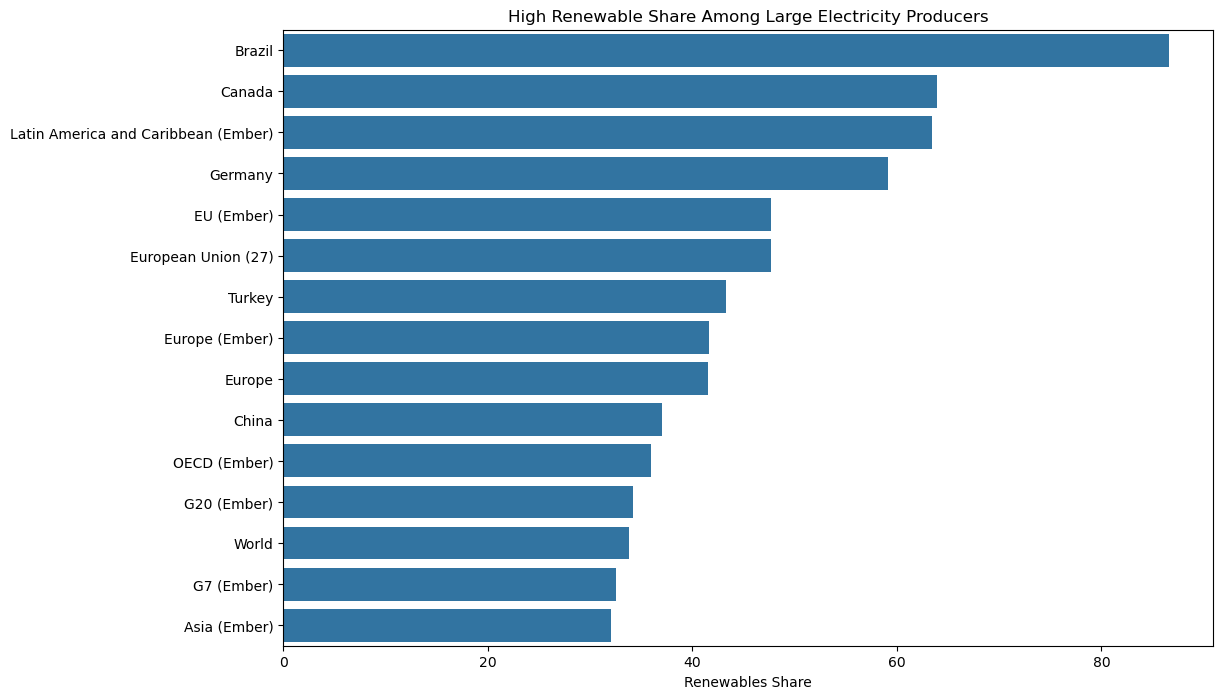

,country,electricity_generation,renewables_share_elec
968,Brazil,750.530,86.601
1195,Canada,652.440,63.900
3537,Latin America and Caribbean (Ember),1846.940,63.475
2649,Germany,500.470,59.092
1843,EU (Ember),2797.090,47.727
2321,European Union (27),2797.090,47.727
6965,Turkey,353.860,43.257
2278,Europe (Ember),5101.690,41.604
2203,Europe,4626.240,41.551
1412,China,10583.360,37.044


In [23]:
large_scale = latest_df[
    latest_df["electricity_generation"] > latest_df["electricity_generation"].quantile(0.75)
]

large_scale = large_scale.sort_values(
    "renewables_share_elec",
    ascending=False
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=large_scale.head(15),
    x="renewables_share_elec",
    y="country"
)

plt.title("High Renewable Share Among Large Electricity Producers")
plt.xlabel("Renewables Share")
plt.ylabel("")
plt.show()

large_scale[[
    "country",
    "electricity_generation",
    "renewables_share_elec"
]].head(15)

## Analysis

This comparison is more informative than simple renewable rankings because it filters out very small electricity systems.

Countries appearing here demonstrate that high renewable penetration can scale beyond niche or geographically isolated grids.